<h1>Data Science and Big Data Analytics Mini Project</h1>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
df = pd.read_csv("covid_vaccine_statewise.csv")

In [3]:
print("Dataset Info:\n")
print(df.info())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7845 entries, 0 to 7844
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Updated On                           7845 non-null   object 
 1   State                                7845 non-null   object 
 2   Total Doses Administered             7621 non-null   float64
 3   Sessions                             7621 non-null   float64
 4    Sites                               7621 non-null   float64
 5   First Dose Administered              7621 non-null   float64
 6   Second Dose Administered             7621 non-null   float64
 7   Male (Doses Administered)            7461 non-null   float64
 8   Female (Doses Administered)          7461 non-null   float64
 9   Transgender (Doses Administered)     7461 non-null   float64
 10   Covaxin (Doses Administered)        7621 non-null   float64
 11  CoviShield (Dos

In [4]:
print("\nDataset Summary Statistics:\n")
print(df.describe(include='all'))


Dataset Summary Statistics:

        Updated On  State  Total Doses Administered      Sessions  \
count         7845   7845              7.621000e+03  7.621000e+03   
unique         213     37                       NaN           NaN   
top     16/01/2021  Delhi                       NaN           NaN   
freq            37    213                       NaN           NaN   
mean           NaN    NaN              9.188171e+06  4.792358e+05   
std            NaN    NaN              3.746180e+07  1.911511e+06   
min            NaN    NaN              7.000000e+00  0.000000e+00   
25%            NaN    NaN              1.356570e+05  6.004000e+03   
50%            NaN    NaN              8.182020e+05  4.547000e+04   
75%            NaN    NaN              6.625243e+06  3.428690e+05   
max            NaN    NaN              5.132284e+08  3.501031e+07   

              Sites   First Dose Administered  Second Dose Administered  \
count    7621.000000             7.621000e+03              7.62100

In [11]:
# Top States by First Dose Administered
latest_data = df.sort_values("Updated On").groupby("State").last()
first_dose = latest_data["First Dose Administered"].fillna(0).sort_values(ascending=False)
print("\nTop States by First Dose Administered:\n")
print(first_dose.head(10))


Top States by First Dose Administered:

State
India             361264651.0
Uttar Pradesh      40485878.0
Maharashtra        33167633.0
Madhya Pradesh     26830212.0
Gujarat            25341390.0
Rajasthan          24972030.0
Karnataka          23841981.0
West Bengal        20837318.0
Bihar              20551758.0
Tamil Nadu         18835602.0
Name: First Dose Administered, dtype: float64


In [6]:
def human_format(num):
    magnitude = 0
    while abs(num) >= 1000:
        magnitude += 1
        num /= 1000.0
    return '%.1f%s' % (num, ['', 'K', 'M', 'B', 'T'][magnitude])

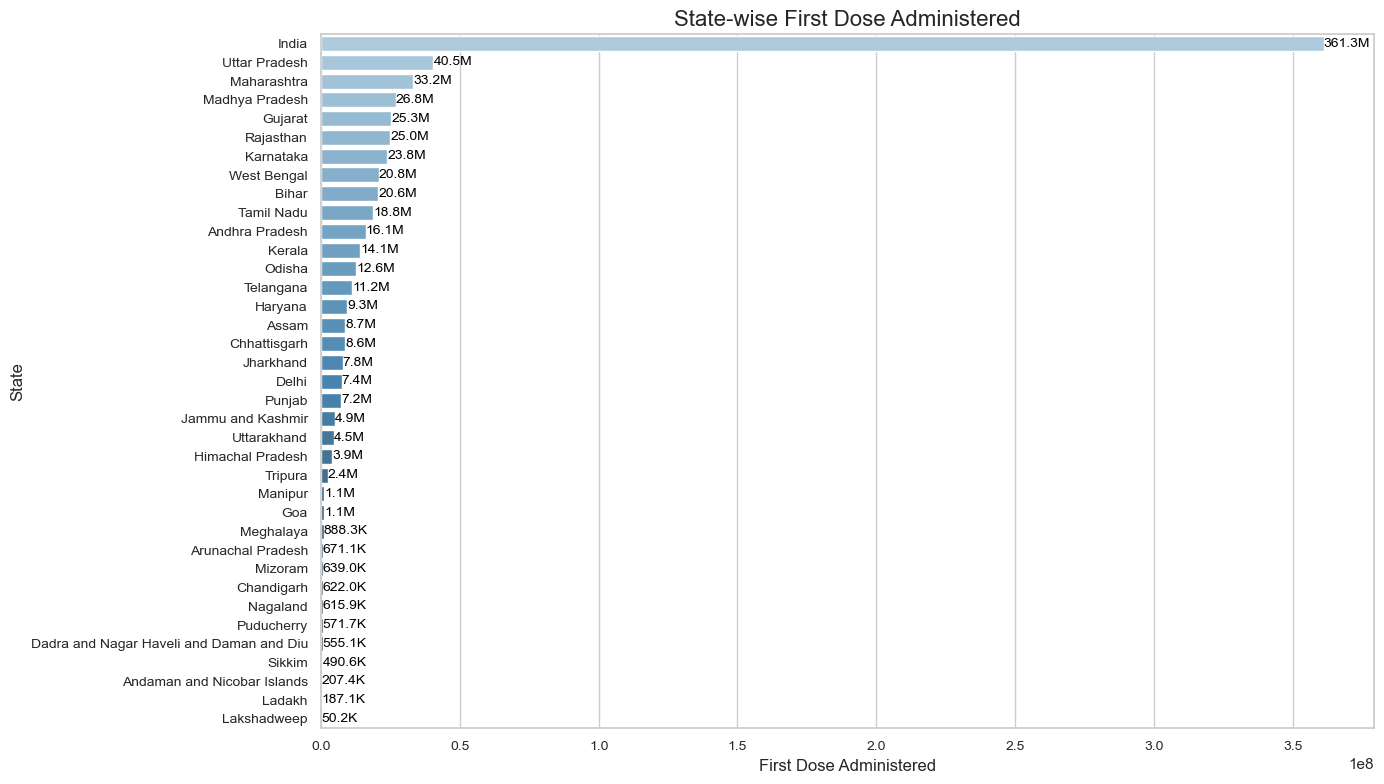

In [8]:
plt.figure(figsize=(14, 8))
sns.barplot(x=first_dose.values, y=first_dose.index, palette="Blues_d")
plt.title("State-wise First Dose Administered", fontsize=16)
plt.xlabel("First Dose Administered", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for i, v in enumerate(first_dose.values):
    plt.text(v, i, human_format(v), color='black', ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
# Top States by Second Dose Administered
second_dose = latest_data["Second Dose Administered"].fillna(0).sort_values(ascending=False)
print("\nTop States by Second Dose Administered:\n")
print(second_dose.head(10))


Top States by Second Dose Administered:

State
India             101848788.0
Maharashtra        11191970.0
West Bengal         8681380.0
Gujarat             7937490.0
Uttar Pradesh       7790151.0
Rajasthan           7496590.0
Karnataka           6529233.0
Kerala              6053845.0
Andhra Pradesh      5572592.0
Madhya Pradesh      5168997.0
Name: Second Dose Administered, dtype: float64


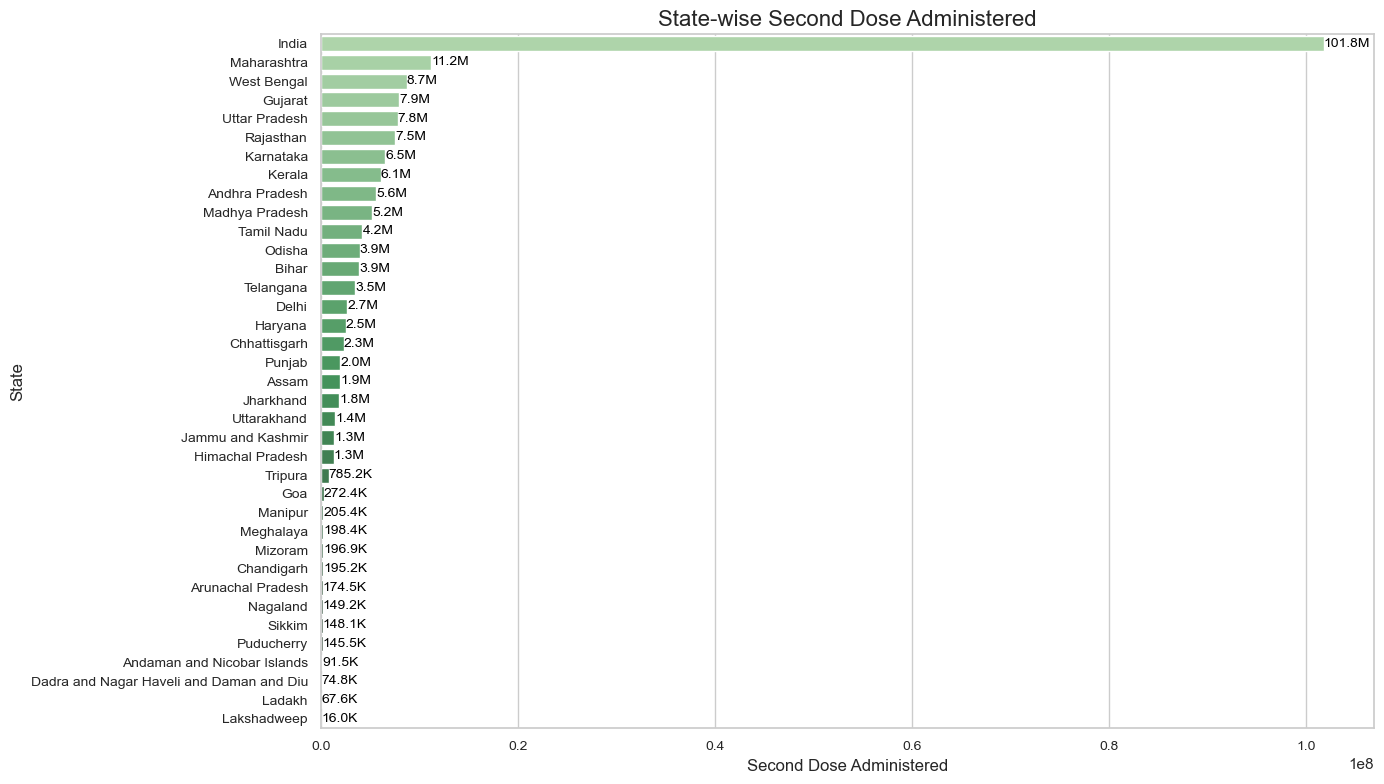

In [10]:
plt.figure(figsize=(14, 8))
sns.barplot(x=second_dose.values, y=second_dose.index, palette="Greens_d")
plt.title("State-wise Second Dose Administered", fontsize=16)
plt.xlabel("Second Dose Administered", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for i, v in enumerate(second_dose.values):
    plt.text(v, i, human_format(v), color='black', ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [12]:
# Gender-wise Vaccination
male_vaccinated = latest_data.loc["India"]["Male(Individuals Vaccinated)"]
female_vaccinated = latest_data.loc["India"]["Female(Individuals Vaccinated)"]

print(f"\nTotal Males Vaccinated in India: {int(male_vaccinated)}")
print(f"Total Females Vaccinated in India: {int(female_vaccinated)}")


Total Males Vaccinated in India: 90095606
Total Females Vaccinated in India: 78271582


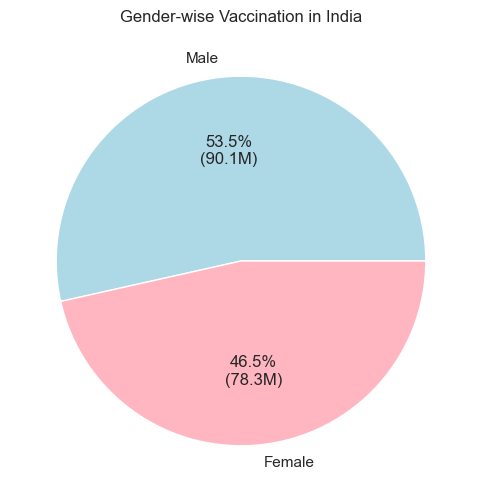

In [13]:
plt.figure(figsize=(6, 6))
plt.pie([male_vaccinated, female_vaccinated],
        labels=["Male", "Female"],
        autopct=lambda p: '{:.1f}%\n({})'.format(p, human_format((p/100)*(male_vaccinated+female_vaccinated))),
        colors=["lightblue", "lightpink"])
plt.title("Gender-wise Vaccination in India")
plt.show()